##실습6.1. API 호출을 통한 단일 프롬프트 예시 실습

In [ ]:
# 한글 폰트 설치
# !apt-get install -y fonts-nanum
# 폰트 설치 후 Colab 메뉴에서 런타임/세션 다시 시작을 선택합니다.

In [ ]:
# !pip install -U openai

In [3]:
# from google.colab import userdata
import os
from dotenv import load_dotenv

# .env 파일 로드
load_dotenv()

# 환경 변수에서 가져오기
api_key = os.getenv("OPENAI_API_KEY")

# Colab에 저장한 Secret에서 API 키 가져와 환경 변수에 등록
os.environ["OPENAI_API_KEY"] = api_key

# 제대로 설정됐는지 확인 (키 값은 출력하지 않도록 주의)
print("API Key configured:", "OPENAI_API_KEY" in os.environ)

API Key configured: True


In [4]:
from openai import OpenAI

# OpenAI 클라이언트 인스턴스 생성
client = OpenAI()

In [5]:
# 단일 프롬프트에 대한 예시 호출
messages = [ {"role": "user", "content": "안녕하세요, 오늘의 날씨는 어떤가요?"} ]
response = client.chat.completions.create(model="gpt-4o-mini", messages=messages)
answer = response.choices[0].message.content  # 모델의 응답 내용
print("모델 응답:", answer)

모델 응답: 안녕하세요! 현재 실시간 날씨 정보를 제공할 수는 없지만, 지역별 날씨 예보는 다양한 날씨 앱이나 웹사이트를 통해 확인하실 수 있습니다. 어떤 지역의 날씨가 궁금하신가요? 예를 들면, 서울, 부산 등 특정 도시의 날씨를 말씀해 주시면 관련된 일반적인 정보나 팁을 제공해 드릴 수 있습니다.


##실습6.2. API 호출을 통한 다중 프롬프트 예시 실습

In [7]:
import time

# 여러 개의 프롬프트 리스트 정의
prompts = [
    "1+1은 무엇인가요?",
    "프랑스의 수도는 어디인가요?",
    "햄릿을 쓴 작가는 누구인가요?",
    "파이썬의 리스트와 튜플의 차이점은 무엇인가요?",
    "파이썬의 창시자는 누구인가요?"
]

# 응답을 저장할 리스트 초기화
responses = []

# 각 프롬프트에 대해 API 호출 실행
for prompt in prompts:
    messages = [ {"role": "user", "content": prompt} ]
    response = client.chat.completions.create(model="gpt-4o-mini", messages=messages, temperature=0)
    answer = response.choices[0].message.content
    responses.append(answer)

    print(f"[Response ID] {response.id}")
    print(f"[프롬프트] {prompt}\n[응답] {answer}\n{'-'*40}")
    time.sleep(1)  # API 호출 간격 조절 (1초)

[Response ID] chatcmpl-C55isPgHF3o3XzvrOlWs6laGBX3n5
[프롬프트] 1+1은 무엇인가요?
[응답] 1 + 1은 2입니다.
----------------------------------------
[Response ID] chatcmpl-C55iuqtk5HxgoT2FpfECJdKdMZUDg
[프롬프트] 프랑스의 수도는 어디인가요?
[응답] 프랑스의 수도는 파리입니다.
----------------------------------------
[Response ID] chatcmpl-C55iwk3kHKLTaIgcTPHqjeWyv4Pbc
[프롬프트] 햄릿을 쓴 작가는 누구인가요?
[응답] 햄릿을 쓴 작가는 윌리엄 셰익스피어(William Shakespeare)입니다. 그는 16세기와 17세기 초에 활동한 영국의 극작가이자 시인으로, 그의 작품은 오늘날까지도 널리 읽히고 공연되고 있습니다. "햄릿"은 그의 가장 유명한 비극 중 하나로, 복수, 배신, 인간 존재의 의미 등을 다루고 있습니다.
----------------------------------------
[Response ID] chatcmpl-C55j0zHvuYaQ7yBj8pgUgBywKwDN5
[프롬프트] 파이썬의 리스트와 튜플의 차이점은 무엇인가요?
[응답] 파이썬에서 리스트(list)와 튜플(tuple)은 모두 여러 개의 값을 저장할 수 있는 데이터 구조이지만, 몇 가지 중요한 차이점이 있습니다.

1. **변경 가능성 (Mutability)**:
   - **리스트**: 변경 가능합니다. 즉, 리스트의 요소를 추가, 삭제, 수정할 수 있습니다.
     ```python
     my_list = [1, 2, 3]
     my_list[0] = 10  # 리스트의 첫 번째 요소를 변경
     my_list.append(4)  # 요소 추가
     ```
   - **튜플**: 변경 불가능합니다. 즉, 튜플의 요소를 수정하거나 추가, 삭제할 수 없습니다.
  

##실습6.3. 응답 시간 출력 실습

In [8]:
import time

# 응답 시간을 기록할 리스트 초기화
response_times = []

for prompt in prompts:
    start = time.time()                      # 시작 시간 기록
    response = client.chat.completions.create(model="gpt-4o-mini",
                                              messages=[{"role":"user","content": prompt}],
                                              temperature=0)
    end = time.time()                        # 종료 시간 기록
    elapsed = end - start                    # 경과 시간 계산 (초 단위)
    response_times.append(elapsed)
    answer = response.choices[0].message.content
    print(f"[Response ID] {response.id}")
    print(f"[질문] {prompt} -> 응답 시간: {elapsed:.2f}초")
    time.sleep(1)  # API 호출 간격 조절 (1초)

[Response ID] chatcmpl-C55k5aoV8JZwUqQhZckR3NZBkX5X8
[질문] 1+1은 무엇인가요? -> 응답 시간: 0.68초
[Response ID] chatcmpl-C55k6Oc9Tn91bMs88rozDeSHcgzIM
[질문] 프랑스의 수도는 어디인가요? -> 응답 시간: 0.63초
[Response ID] chatcmpl-C55k8Xtleo1H31wPgngOf1GW3MJJO
[질문] 햄릿을 쓴 작가는 누구인가요? -> 응답 시간: 2.04초
[Response ID] chatcmpl-C55kBycOsSflbS10ukKBlYr8lnGPJ
[질문] 파이썬의 리스트와 튜플의 차이점은 무엇인가요? -> 응답 시간: 10.35초
[Response ID] chatcmpl-C55kMQ6U0XmQ3dyjp3HL2dTaHUy0s
[질문] 파이썬의 창시자는 누구인가요? -> 응답 시간: 2.40초


In [9]:
messages = [ {"role": "user", "content": "안녕하세요, 오늘의 날씨는 어떤가요?"} ]
response = client.chat.completions.create(model="gpt-4o-mini", messages=messages)
usage = response.usage
print(usage)

CompletionUsage(completion_tokens=69, prompt_tokens=19, total_tokens=88, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0))


##실습6.4. 응답 내 토큰 사용량 추출 및 통계 실습

In [10]:
import math

# 토큰 사용량과 응답 저장을 위한 리스트 초기화
results = []  # 각 프롬프트별 결과(dict)를 모아둘 리스트

for prompt in prompts:
    response = client.chat.completions.create(model="gpt-4o-mini",
                                              messages=[{"role":"user","content": prompt}],
                                              temperature=0)
    content = response.choices[0].message.content
    usage = response.usage  # 토큰 사용량 정보
    prompt_tokens = usage.prompt_tokens
    answer_tokens = usage.completion_tokens
    total_tokens = usage.total_tokens
    results.append({
        "prompt": prompt,
        "response_text": content,
        "prompt_tokens": prompt_tokens,
        "answer_tokens": answer_tokens,
        "total_tokens": total_tokens
    })
    time.sleep(1)  # API 호출 간격 조절 (1초)

# 수집한 토큰 사용량 출력 및 통계 계산
total_token_counts = [res["total_tokens"] for res in results]
print("프롬프트별 토큰 사용량:", total_token_counts)
print("평균 총 토큰 수:", sum(total_token_counts) / len(total_token_counts))
print("최대 총 토큰 수:", max(total_token_counts), "/ 최소 총 토큰 수:", min(total_token_counts))

프롬프트별 토큰 사용량: [24, 27, 116, 516, 116]
평균 총 토큰 수: 159.8
최대 총 토큰 수: 516 / 최소 총 토큰 수: 24


##실습6.5. 응답 패턴 비교 분석 실습

In [11]:
for res in results:
    text = res["response_text"]
    length_chars = len(text)            # 응답 글자수
    polite = "예" if ("니다." in text or "요." in text) else "아니오"  # 존댓말 여부 판단
    keyword = ""
    if "셰익스피어" in text:
        keyword = "셰익스피어 포함"
    elif "파리" in text:
        keyword = "파리 포함"
    elif "귀도" in text or "Guido" in text:
        keyword = "귀도 포함"
    elif "변경" in text:
        keyword = "변경 관련 내용 포함"
    else:
        keyword = "(특정 키워드 없음)"
    print(f"응답: '{text[:30]}...' | 글자수: {length_chars}, 존댓말 사용: {polite}, 키워드 체크: {keyword}")

응답: '1 + 1은 2입니다....' | 글자수: 12, 존댓말 사용: 예, 키워드 체크: (특정 키워드 없음)
응답: '프랑스의 수도는 파리입니다....' | 글자수: 15, 존댓말 사용: 예, 키워드 체크: 파리 포함
응답: '햄릿을 쓴 작가는 윌리엄 셰익스피어(William Sh...' | 글자수: 164, 존댓말 사용: 예, 키워드 체크: 셰익스피어 포함
응답: '파이썬에서 리스트(list)와 튜플(tuple)은 모두...' | 글자수: 1076, 존댓말 사용: 예, 키워드 체크: 변경 관련 내용 포함
응답: '파이썬의 창시자는 귀도 반 로썸(Guido van Ro...' | 글자수: 157, 존댓말 사용: 예, 키워드 체크: 귀도 포함


##실습6.6. Pandas 및 시각화 도구를 통한 결과 표 및 그래프 실습

In [12]:
import pandas as pd

# results 리스트를 DataFrame으로 변환
df = pd.DataFrame(results)
df

,prompt,response_text,prompt_tokens,answer_tokens,total_tokens
0,1+1은 무엇인가요?,1 + 1은 2입니다.,15,9,24
1,프랑스의 수도는 어디인가요?,프랑스의 수도는 파리입니다.,17,10,27
2,햄릿을 쓴 작가는 누구인가요?,햄릿을 쓴 작가는 윌리엄 셰익스피어(William Shakespeare)입니다. 그...,19,97,116
3,파이썬의 리스트와 튜플의 차이점은 무엇인가요?,파이썬에서 리스트(list)와 튜플(tuple)은 모두 여러 값을 저장할 수 있는 ...,26,490,516
4,파이썬의 창시자는 누구인가요?,파이썬의 창시자는 귀도 반 로썸(Guido van Rossum)입니다. 그는 198...,19,97,116


In [13]:
# 분석 및 평가 결과 컬럼 추가
df["response_length"] = df["response_text"].apply(len)  # 응답 글자수
df

,prompt,response_text,prompt_tokens,answer_tokens,total_tokens,response_length
0,1+1은 무엇인가요?,1 + 1은 2입니다.,15,9,24,12
1,프랑스의 수도는 어디인가요?,프랑스의 수도는 파리입니다.,17,10,27,15
2,햄릿을 쓴 작가는 누구인가요?,햄릿을 쓴 작가는 윌리엄 셰익스피어(William Shakespeare)입니다. 그...,19,97,116,164
3,파이썬의 리스트와 튜플의 차이점은 무엇인가요?,파이썬에서 리스트(list)와 튜플(tuple)은 모두 여러 값을 저장할 수 있는 ...,26,490,516,1076
4,파이썬의 창시자는 누구인가요?,파이썬의 창시자는 귀도 반 로썸(Guido van Rossum)입니다. 그는 198...,19,97,116,157


In [14]:
# 정답여부(auto 평가): 각 질문별로 기대하는 키워드/정답이 응답에 포함되었는지 (True/False)
expected_keywords = [
    ["2"],              # Q1 정답 "2"
    ["파리"],           # Q2 정답 "파리"
    ["셰익스피어"],      # Q3 정답 "셰익스피어"
    ["변경"],           # Q4 키워드 "변경" (차이점 설명에 포함되어야 할 핵심어)
    ["귀도", "Guido"]   # Q5 정답 "귀도" (영문/한글 모두 체크)
]
df["is_correct"] = [ any((kw in res["response_text"]) for kw in expected_keywords[i])
                     for i, res in df.iterrows() ]

df

,prompt,response_text,prompt_tokens,answer_tokens,total_tokens,response_length,is_correct
0,1+1은 무엇인가요?,1 + 1은 2입니다.,15,9,24,12,True
1,프랑스의 수도는 어디인가요?,프랑스의 수도는 파리입니다.,17,10,27,15,True
2,햄릿을 쓴 작가는 누구인가요?,햄릿을 쓴 작가는 윌리엄 셰익스피어(William Shakespeare)입니다. 그...,19,97,116,164,True
3,파이썬의 리스트와 튜플의 차이점은 무엇인가요?,파이썬에서 리스트(list)와 튜플(tuple)은 모두 여러 값을 저장할 수 있는 ...,26,490,516,1076,True
4,파이썬의 창시자는 누구인가요?,파이썬의 창시자는 귀도 반 로썸(Guido van Rossum)입니다. 그는 198...,19,97,116,157,True


In [15]:
# 필요한 컬럼만 선택하여 출력
df[["prompt", "prompt_tokens", "answer_tokens", "total_tokens", "response_length", "is_correct"]]

,prompt,prompt_tokens,answer_tokens,total_tokens,response_length,is_correct
0,1+1은 무엇인가요?,15,9,24,12,True
1,프랑스의 수도는 어디인가요?,17,10,27,15,True
2,햄릿을 쓴 작가는 누구인가요?,19,97,116,164,True
3,파이썬의 리스트와 튜플의 차이점은 무엇인가요?,26,490,516,1076,True
4,파이썬의 창시자는 누구인가요?,19,97,116,157,True


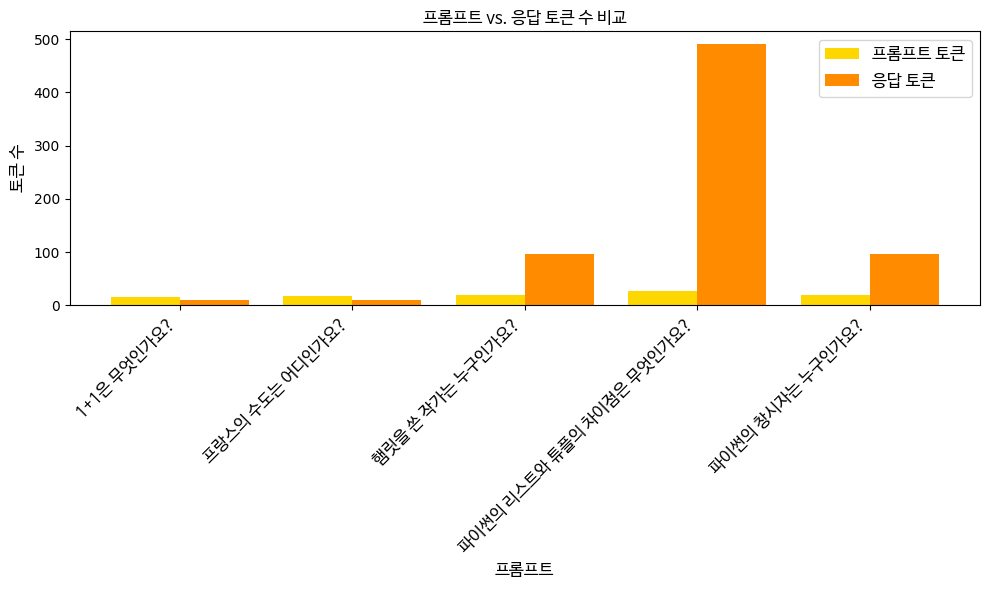

In [18]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'  # 나눔바른고딕 경로
fontprop = fm.FontProperties(fname=font_path, size=12)

# 프롬프트별 입력 토큰 vs 출력 토큰 비교 그래프
plt.figure(figsize=(10, 6))

# 막대 폭 및 위치 설정
bar_width = 0.4  # 막대 폭
x_pos_prompt = df.index  # 프롬프트 막대 위치
x_pos_answer = df.index + bar_width  # 응답 막대 위치 (프롬프트 막대 옆)

plt.bar(x_pos_prompt, df['prompt_tokens'], color='gold', width=bar_width, label='프롬프트 토큰')
plt.bar(x_pos_answer, df['answer_tokens'], color='darkorange', width=bar_width, label='응답 토큰')

plt.xticks(df.index + bar_width/2, df['prompt'], rotation=45, ha='right', fontproperties=fontprop)  # X축 눈금 설정 (막대 중앙에 위치)
plt.xlabel('프롬프트', fontproperties=fontprop)
plt.ylabel('토큰 수', fontproperties=fontprop)
plt.title('프롬프트 vs. 응답 토큰 수 비교', fontproperties=fontprop)
plt.legend(prop=fontprop)
plt.tight_layout()
plt.show()

##실습6.7. 실습 결과 데이터 CSV/JSON 저장 실습

In [17]:
# DataFrame을 CSV 파일로 저장 (인덱스 제외)
df.to_csv("results.csv", index=False)

# DataFrame을 JSON 파일로 저장 (UTF-8 인코딩 유지)
df.to_json("results.json", orient="records", force_ascii=False)